In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [43]:
def display_image(img, cmap=None):
    """Display an image in the notebook"""
    if len(img.shape) == 3 and img.shape[2] == 3:  # Color image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb, cmap=cmap)
    else:  # Grayscale image
        plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def download_haarcascade():
    """Download the Haar Cascade file for face detection"""
    import urllib.request
    import os
    
    # URL for the Haar Cascade file
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    filename = "haarcascade_frontalface_default.xml"
    
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print("Haar Cascade file downloaded successfully.")
    else:
        print("Haar Cascade file already exists.")
    
    return filename

In [44]:
def head_count_haar(image_path, scaleFactor=1.1, minNeighbors=5):
    """
    Count heads using Haar Cascade classifier
    """
    # Download the Haar Cascade file if not exists
    cascade_path = download_haarcascade()
    
    # Load the classifier
    face_cascade = cv2.CascadeClassifier(cascade_path)
    
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    
    # Draw rectangles around the faces and count them
    count = 0
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        count += 1
        cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Display the result
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

In [45]:
def head_count_hog(image_path):
    """
    Count heads using HOG descriptor and SVM classifier
    """
    # Initialize the HOG descriptor/person detector
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    # Resize image for better detection
    img = cv2.resize(img, (640, 480))
    
    # Detect people in the image
    boxes, weights = hog.detectMultiScale(img, winStride=(4, 4), padding=(8, 8), scale=1.05)
    
    # Draw rectangles around the detected people
    count = 0
    for i, (x, y, w, h) in enumerate(boxes):
        if weights[i] > 0.7:  # Confidence threshold
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            count += 1
            cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Display the result
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

In [46]:
def real_time_head_count(method='haar', duration=10):
    """
    Perform real-time head counting from webcam
    """
    # Initialize video capture
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam")
        return
    
    # Choose the detection method
    if method == 'haar':
        cascade_path = download_haarcascade()
        face_cascade = cv2.CascadeClassifier(cascade_path)
    else:  # hog
        hog = cv2.HOGDescriptor()
        hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    # Set up display
    fig = plt.figure(figsize=(10, 8))
    
    start_time = cv2.getTickCount()
    
    try:
        while True:
            # Calculate elapsed time
            elapsed_time = (cv2.getTickCount() - start_time) / cv2.getTickFrequency()
            if elapsed_time > duration:
                break
                
            # Read frame from webcam
            ret, frame = cap.read()
            if not ret:
                break
                
            # Resize frame for faster processing
            frame = cv2.resize(frame, (640, 480))
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # Detect heads based on selected method
            count = 0
            if method == 'haar':
                faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
                count = len(faces)
                for (x, y, w, h) in faces:
                    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            else:  # hog
                boxes, weights = hog.detectMultiScale(frame, winStride=(4, 4), padding=(8, 8), scale=1.05)
                for i, (x, y, w, h) in enumerate(boxes):
                    if weights[i] > 0.7:
                        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                        count += 1
            
            # Display count on frame
            cv2.putText(frame, f"Count: {count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.putText(frame, f"Time: {int(duration - elapsed_time)}s", (10, 70), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            # Display the frame in the notebook
            clear_output(wait=True)
            display_image(frame)
            
    except KeyboardInterrupt:
        print("Interrupted by user")
    
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Webcam released")

Haar Cascade file already exists.
Detected 1 people using Haar Cascades


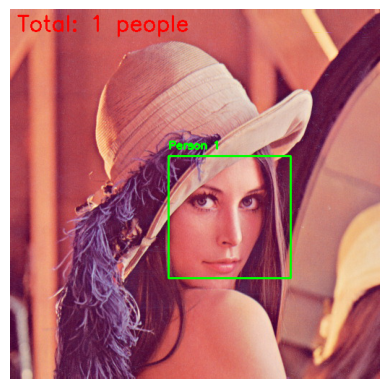

In [47]:
# Example 1: Head count using Haar Cascades on an image
# Download a sample image first or use your own
import urllib.request
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "sample_image.jpg")

count, result_img = head_count_haar("sample_image.jpg")
print(f"Detected {count} people using Haar Cascades")
display_image(result_img)

Detected 0 people using HOG


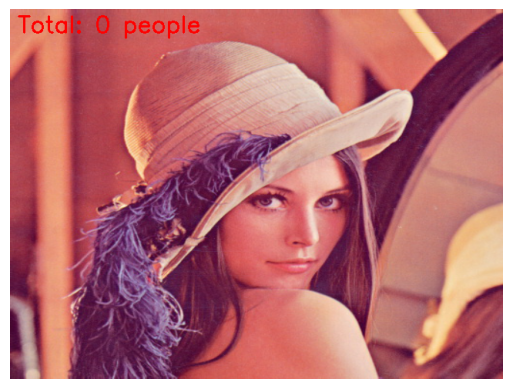

In [48]:
# Example 2: Head count using HOG on the same image
count, result_img = head_count_hog("sample_image.jpg")
print(f"Detected {count} people using HOG")
display_image(result_img)

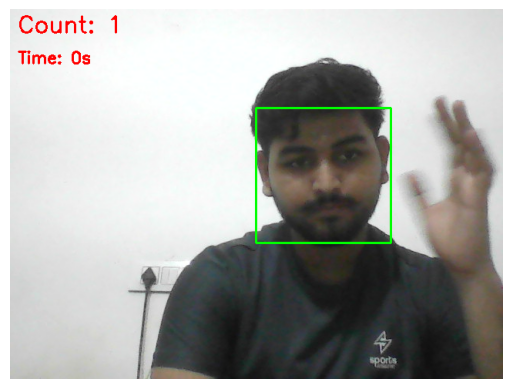

Webcam released


In [33]:
# Example 3: Real-time head count from webcam (run for 10 seconds)
# Note: This will use your webcam
real_time_head_count(method='haar', duration=10)

Head Count using Haar Cascades:
Haar Cascade file already exists.
Detected 1 people


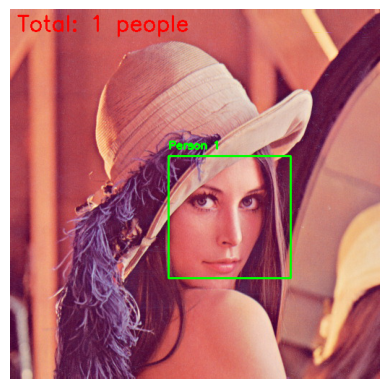


Head Count using HOG:
Detected 0 people


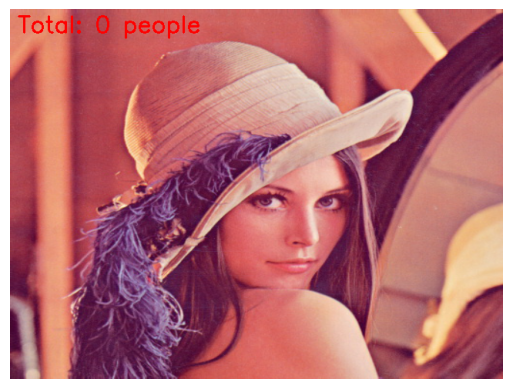

In [34]:
# Head Count Project with OpenCV

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import urllib.request
import os

def download_haarcascade():
    """Download the Haar Cascade file for face detection"""
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    filename = "haarcascade_frontalface_default.xml"
    
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print("Haar Cascade file downloaded successfully.")
    else:
        print("Haar Cascade file already exists.")
    
    return filename

def display_image(img, cmap=None):
    """Display an image in the notebook"""
    if len(img.shape) == 3 and img.shape[2] == 3:  # Color image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb, cmap=cmap)
    else:  # Grayscale image
        plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def head_count_haar(image_path, scaleFactor=1.1, minNeighbors=5):
    """Count heads using Haar Cascade classifier"""
    cascade_path = download_haarcascade()
    face_cascade = cv2.CascadeClassifier(cascade_path)
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    
    count = 0
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        count += 1
        cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

def head_count_hog(image_path):
    """Count heads using HOG descriptor and SVM classifier"""
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    img = cv2.resize(img, (640, 480))
    boxes, weights = hog.detectMultiScale(img, winStride=(4, 4), padding=(8, 8), scale=1.05)
    
    count = 0
    for i, (x, y, w, h) in enumerate(boxes):
        if weights[i] > 0.7:
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            count += 1
            cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

# Download sample image
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "sample_image.jpg")

# Example usage
print("Head Count using Haar Cascades:")
count_haar, img_haar = head_count_haar("sample_image.jpg")
print(f"Detected {count_haar} people")
display_image(img_haar)

print("\nHead Count using HOG:")
count_hog, img_hog = head_count_hog("sample_image.jpg")
print(f"Detected {count_hog} people")
display_image(img_hog)

Head Count using Haar Cascades:
Haar Cascade file already exists.
Detected 1 people


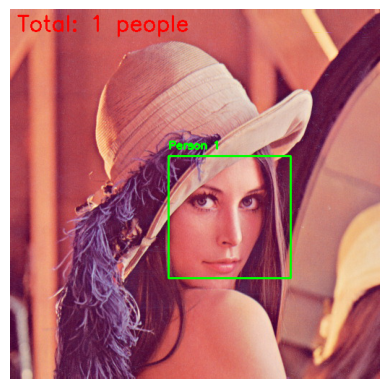


Head Count using HOG:
Detected 0 people


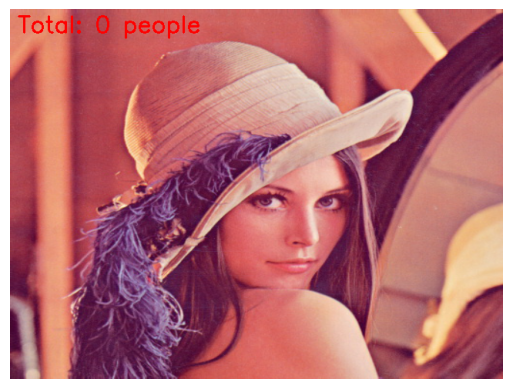

In [35]:
# Head Count Project with OpenCV - Fixed Webcam Version

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Image
import urllib.request
import os
import time

def download_haarcascade():
    """Download the Haar Cascade file for face detection"""
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    filename = "haarcascade_frontalface_default.xml"
    
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
        print("Haar Cascade file downloaded successfully.")
    else:
        print("Haar Cascade file already exists.")
    
    return filename

def display_image(img, cmap=None):
    """Display an image in the notebook"""
    if len(img.shape) == 3 and img.shape[2] == 3:  # Color image
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb, cmap=cmap)
    else:  # Grayscale image
        plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.show()

def head_count_haar(image_path, scaleFactor=1.1, minNeighbors=5):
    """Count heads using Haar Cascade classifier"""
    cascade_path = download_haarcascade()
    face_cascade = cv2.CascadeClassifier(cascade_path)
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    
    count = 0
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        count += 1
        cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

def head_count_hog(image_path):
    """Count heads using HOG descriptor and SVM classifier"""
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None
    
    img = cv2.resize(img, (640, 480))
    boxes, weights = hog.detectMultiScale(img, winStride=(4, 4), padding=(8, 8), scale=1.05)
    
    count = 0
    for i, (x, y, w, h) in enumerate(boxes):
        if weights[i] > 0.7:
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            count += 1
            cv2.putText(img, f"Person {count}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.putText(img, f"Total: {count} people", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    return count, img

def real_time_head_count_jupyter(method='haar', duration=10):
    """
    Perform real-time head counting from webcam in Jupyter Notebook
    This version saves frames and displays them as images
    """
    # Initialize video capture
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam")
        print("Trying alternative camera index...")
        cap = cv2.VideoCapture(1)
        if not cap.isOpened():
            print("Could not open any camera")
            return
    
    # Choose the detection method
    if method == 'haar':
        cascade_path = download_haarcascade()
        face_cascade = cv2.CascadeClassifier(cascade_path)
        detector_type = "Haar Cascade"
    else:  # hog
        hog = cv2.HOGDescriptor()
        hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
        detector_type = "HOG"
    
    print(f"Starting real-time head count using {detector_type} for {duration} seconds")
    print("Press 'q' in the camera window to stop early")
    
    start_time = time.time()
    frame_count = 0
    
    try:
        while (time.time() - start_time) < duration:
            # Read frame from webcam
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame")
                break
                
            # Resize frame for faster processing
            frame = cv2.resize(frame, (640, 480))
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # Detect heads based on selected method
            count = 0
            if method == 'haar':
                faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
                count = len(faces)
                for (x, y, w, h) in faces:
                    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            else:  # hog
                boxes, weights = hog.detectMultiScale(frame, winStride=(4, 4), padding=(8, 8), scale=1.05)
                for i, (x, y, w, h) in enumerate(boxes):
                    if weights[i] > 0.7:
                        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                        count += 1
            
            # Display count on frame
            cv2.putText(frame, f"Count: {count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.putText(frame, f"Time: {int(duration - (time.time() - start_time))}s", 
                        (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            cv2.putText(frame, f"Method: {detector_type}", (10, 110), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            # Save the frame as an image file
            filename = f"frame_{frame_count}.jpg"
            cv2.imwrite(filename, frame)
            
            # Display the image in Jupyter
            clear_output(wait=True)
            display(Image(filename=filename))
            
            # Wait a bit before next frame
            time.sleep(0.1)
            frame_count += 1
            
            # Check for early exit (this won't work in Jupyter, but keeping for completeness)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
    except Exception as e:
        print(f"An error occurred: {e}")
    
    finally:
        cap.release()
        print("Webcam released")
        
        # Clean up temporary frame files
        for i in range(frame_count):
            try:
                os.remove(f"frame_{i}.jpg")
            except:
                pass

# Download sample image
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "sample_image.jpg")

# Example usage
print("Head Count using Haar Cascades:")
count_haar, img_haar = head_count_haar("sample_image.jpg")
print(f"Detected {count_haar} people")
display_image(img_haar)

print("\nHead Count using HOG:")
count_hog, img_hog = head_count_hog("sample_image.jpg")
print(f"Detected {count_hog} people")
display_image(img_hog)

# Run real-time head count (uncomment to run)
# print("\nStarting real-time head count (10 seconds)...")
# real_time_head_count_jupyter(method='haar', duration=10)

In [38]:
from IPython.display import HTML, display
import ipywidgets as widgets

# Create a button to trigger webcam access
button = widgets.Button(description="Start Webcam")
output = widgets.Output()

display(button, output)

def on_button_clicked(b):
    with output:
        # This JavaScript code will access the webcam
        js_code = """
        <script>
        navigator.mediaDevices.getUserMedia({ video: true })
          .then(function(stream) {
            console.log("Webcam accessed successfully");
            // You would need to send this stream to your Python code
            // This typically requires additional libraries like ipywebrtc
          })
          .catch(function(err) {
            console.log("An error occurred: " + err);
          });
        </script>
        """
        display(HTML(js_code))
        print("Attempting to access webcam... Check browser permissions.")

button.on_click(on_button_clicked)

Button(description='Start Webcam', style=ButtonStyle())

Output()

In [39]:
pip install ipywebrtc

Note: you may need to restart the kernel to use updated packages.


In [40]:
def head_count_video(video_path, method='haar', output_file='output_video.avi'):
    """Count heads in a video file"""
    # Initialize video capture
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Initialize video writer
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_file, fourcc, fps, (width, height))
    
    # Choose the detection method
    if method == 'haar':
        cascade_path = download_haarcascade()
        face_cascade = cv2.CascadeClassifier(cascade_path)
    else:  # hog
        hog = cv2.HOGDescriptor()
        hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    frame_count = 0
    people_counts = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect heads
        count = 0
        if method == 'haar':
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
            count = len(faces)
            for (x, y, w, h) in faces:
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        else:  # hog
            boxes, weights = hog.detectMultiScale(frame, winStride=(4, 4), padding=(8, 8), scale=1.05)
            for i, (x, y, w, h) in enumerate(boxes):
                if weights[i] > 0.7:
                    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    count += 1
        
        # Add count to frame
        cv2.putText(frame, f"Count: {count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        cv2.putText(frame, f"Frame: {frame_count}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # Write frame to output video
        out.write(frame)
        people_counts.append(count)
        frame_count += 1
        
        # Display progress
        if frame_count % 30 == 0:
            print(f"Processed {frame_count} frames, current count: {count}")
    
    cap.release()
    out.release()
    
    print(f"Video processing complete. Average people count: {sum(people_counts)/len(people_counts):.2f}")
    print(f"Output saved to {output_file}")
    
    return people_counts

# Example usage with a video file
# people_counts = head_count_video("your_video.mp4", method='haar')